Open rate for Version A: 0.1220
Open rate for Version B: 0.1440
Open rate for Version C: 0.1667
ANOVA F-statistic: 6.0746, P-value: 0.0023
The difference in open rates between the versions is statistically significant.


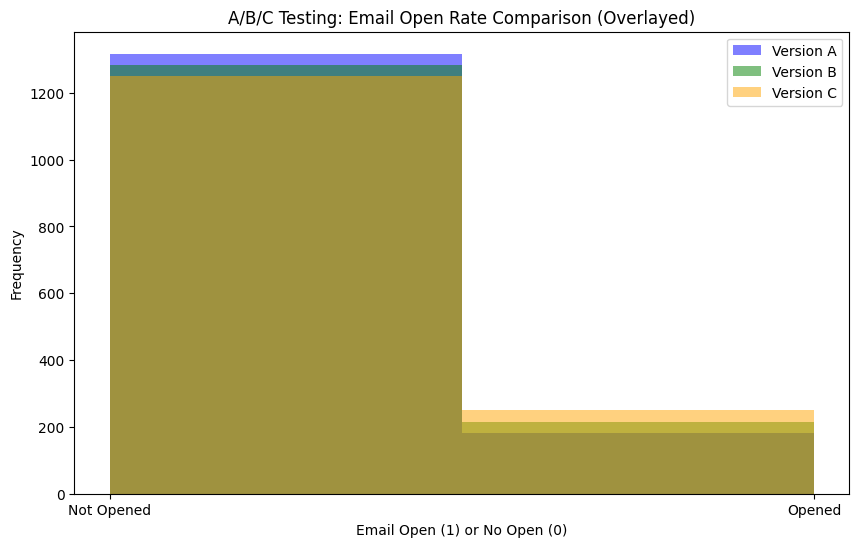

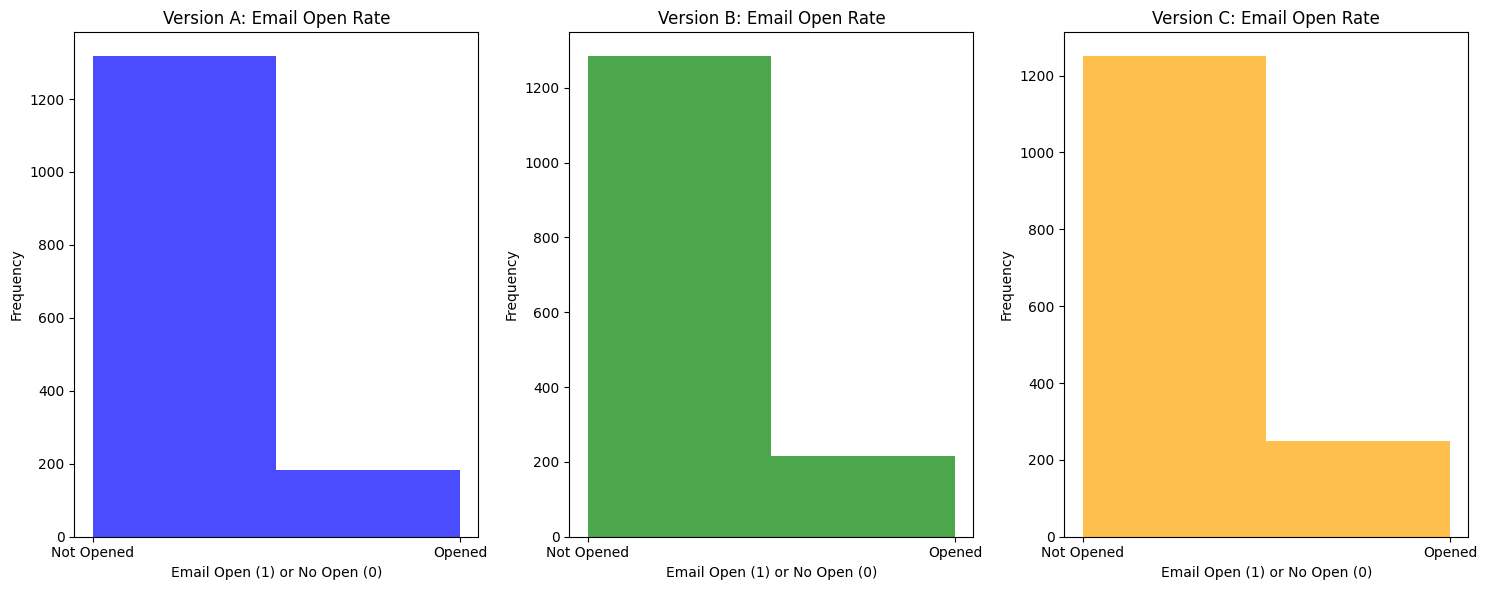

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

# Step 1: Simulating Data
np.random.seed(42)  # For reproducibility

# Simulating a sample of 1,500 visitors for each email version (A, B, C)
n = 1500  # Sample size for each group

# Assume Version A has a 12% open rate
# Assume Version B has a 15% open rate
# Assume Version C has a 18% open rate
open_rate_A = 0.12
open_rate_B = 0.15
open_rate_C = 0.18

# Simulate whether emails were opened (1 for open, 0 for not open) for each group
group_A_data = np.random.binomial(1, open_rate_A, n)
group_B_data = np.random.binomial(1, open_rate_B, n)
group_C_data = np.random.binomial(1, open_rate_C, n)

# Step 2: Analyze the Results
# Calculate the average open rate for each group
open_rate_A_actual = group_A_data.mean()
open_rate_B_actual = group_B_data.mean()
open_rate_C_actual = group_C_data.mean()

# Perform a one-way ANOVA to compare the means of open rates across all three groups
f_stat, p_value_anova = stats.f_oneway(group_A_data, group_B_data, group_C_data)

# Step 3: Display Results
print(f"Open rate for Version A: {open_rate_A_actual:.4f}")
print(f"Open rate for Version B: {open_rate_B_actual:.4f}")
print(f"Open rate for Version C: {open_rate_C_actual:.4f}")
print(f"ANOVA F-statistic: {f_stat:.4f}, P-value: {p_value_anova:.4f}")

# Step 4: Interpretation of Results
if p_value_anova < 0.05:
    print("The difference in open rates between the versions is statistically significant.")
else:
    print("The difference in open rates between the versions is not statistically significant.")

# Step 5: Visualize the Results (Three versions A, B, and C)

# Overlayed Histogram (as before)
plt.figure(figsize=(10, 6))

# Plot for Version A
plt.hist(group_A_data, bins=2, alpha=0.5, label='Version A', color='blue')

# Plot for Version B
plt.hist(group_B_data, bins=2, alpha=0.5, label='Version B', color='green')

# Plot for Version C
plt.hist(group_C_data, bins=2, alpha=0.5, label='Version C', color='orange')

# Title and Labels
plt.title('A/B/C Testing: Email Open Rate Comparison (Overlayed)')
plt.xlabel('Email Open (1) or No Open (0)')
plt.ylabel('Frequency')

# Adding labels to bins
plt.xticks([0, 1], ['Not Opened', 'Opened'])  # Label the bins for clarity

# Display legend
plt.legend()

# Show the plot
plt.show()

# Separate Histograms (added part)
plt.figure(figsize=(15, 6))

# Plot for Version A (Separate)
plt.subplot(1, 3, 1)
plt.hist(group_A_data, bins=2, alpha=0.7, color='blue')
plt.title('Version A: Email Open Rate')
plt.xlabel('Email Open (1) or No Open (0)')
plt.ylabel('Frequency')
plt.xticks([0, 1], ['Not Opened', 'Opened'])  # Label the bins for clarity

# Plot for Version B (Separate)
plt.subplot(1, 3, 2)
plt.hist(group_B_data, bins=2, alpha=0.7, color='green')
plt.title('Version B: Email Open Rate')
plt.xlabel('Email Open (1) or No Open (0)')
plt.ylabel('Frequency')
plt.xticks([0, 1], ['Not Opened', 'Opened'])  # Label the bins for clarity

# Plot for Version C (Separate)
plt.subplot(1, 3, 3)
plt.hist(group_C_data, bins=2, alpha=0.7, color='orange')
plt.title('Version C: Email Open Rate')
plt.xlabel('Email Open (1) or No Open (0)')
plt.ylabel('Frequency')
plt.xticks([0, 1], ['Not Opened', 'Opened'])  # Label the bins for clarity

# Show the separate histograms
plt.tight_layout()
plt.show()

# Step 6: Save the Results to a DataFrame for Further Analysis
data = pd.DataFrame({
    'Email_Version': ['A']*n + ['B']*n + ['C']*n,
    'Email_Open': np.concatenate([group_A_data, group_B_data, group_C_data])
})

# Save to CSV
data.to_csv('ab_test_email_open_with_anova.csv', index=False)
